In [1]:
# Import neccessary libraries 
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold, cross_validate

In [2]:
# Load dataframe 
df = pd.read_parquet("../data/processed/sentinel_cleaned_data.parquet")

In [3]:
# Dataframe visualization 
df.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,hourOfDay,errorBalanceOrig,errorBalanceDest,fractionAmount
0,1.0,181.00,181.0,0.0,0.0,0.00,1.0,1.0,0.00,181.0,0.994505
1,0.0,181.00,181.0,0.0,21182.0,0.00,1.0,1.0,0.00,21363.0,0.994505
2,0.0,229133.94,15325.0,0.0,5083.0,51513.44,0.0,1.0,213808.94,182703.5,14.950668
3,1.0,215310.30,705.0,0.0,22425.0,0.00,0.0,1.0,214605.30,237735.3,304.972096
4,1.0,311685.89,10835.0,0.0,6267.0,2719172.89,0.0,1.0,300850.89,-2401220.0,28.763925


In [4]:
# Feature-target split
X = df.drop(columns = ["isFraud"])
y = df["isFraud"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train set dimensions
print(f"X_train size : {X_train.shape}")
print(f"y_train size : {y_train.shape}")

X_train size : (2216327, 10)
y_train size : (2216327,)


In [5]:
# Handling class imbalance (fraud class weighting)
weight_penalty = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Computed class weight: {weight_penalty:.2f} (1 Fraud case is equivalent to {weight_penalty:.0f} non-fraud cases)")

# Model initialization
model = xgb.XGBClassifier(
    scale_pos_weight = weight_penalty,
    random_state = 42,
    eval_metric = 'aucpr'
)

Computed class weight: 336.34 (1 Fraud case is equivalent to 336 non-fraud cases)


In [6]:
# Model training and execution time measurement
start_time = time.time()
model.fit(X_train, y_train)
end_time = time.time()

print(f"Training time : {round(end_time - start_time, 2)} seconds")

Training time : 23.88 seconds


In [7]:
# Model preddiction on test data
y_pred = model.predict(X_test)

              precision    recall  f1-score   support

         0.0     1.0000    0.9990    0.9995    552439
         1.0     0.7433    0.9903    0.8492      1643

    accuracy                         0.9990    554082
   macro avg     0.8716    0.9946    0.9243    554082
weighted avg     0.9992    0.9990    0.9990    554082



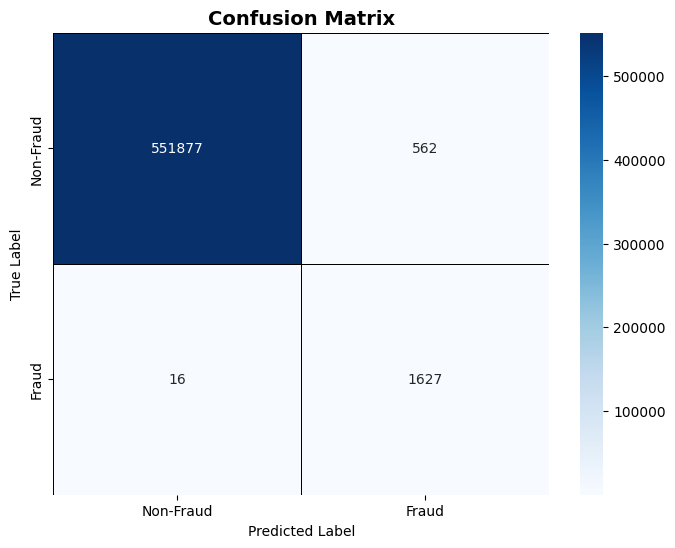

In [8]:
# Classification report and Confusion matrix 
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)

# Confusion matrix visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5, linecolor='black', xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])

plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

C:\Users\Jonathan\AppData\Local\Temp\ipykernel_9096\1524434606.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data_importance.score, y=data_importance.index, palette="viridis")


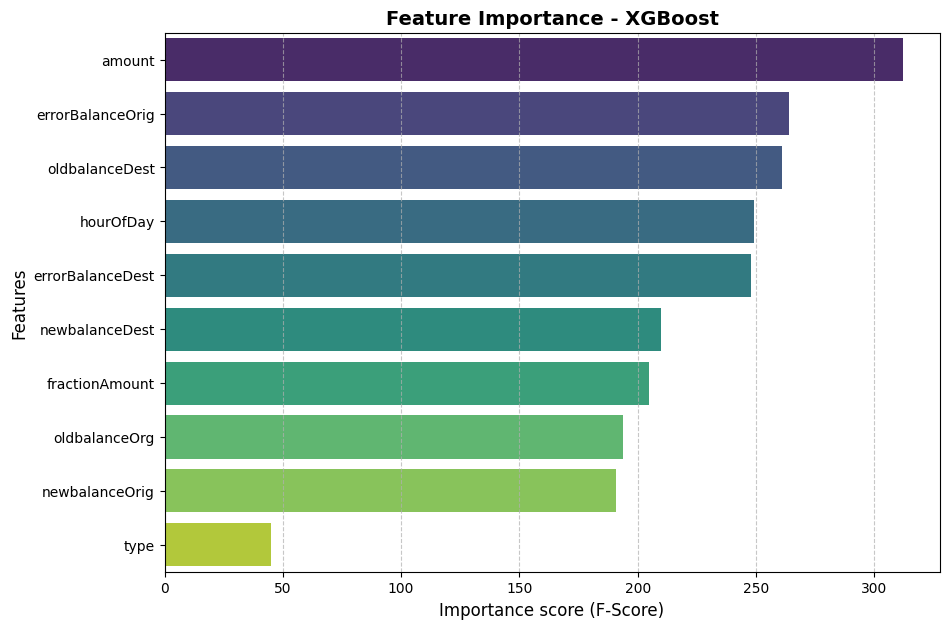

In [9]:
# Extract feature importance scores from the trained XGBoost model
feature_important = model.get_booster().get_score(importance_type='weight')

# Convert importance dictionary to lists
keys = list(feature_important.keys())
values = list(feature_important.values())

# Create a Dataframe and sort features by importance
data_importance = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)

# Plot feature importance
plt.figure(figsize = (10,7))
sns.barplot(x=data_importance.score, y=data_importance.index, palette="viridis")

plt.title("Feature Importance - XGBoost", fontsize=14, fontweight='bold')
plt.xlabel("Importance score (F-Score)", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

In [10]:
# Cross-validation setup and execution time measurement
start_time = time.time()

# Define stratified k-fold cross-validation (preserves class distribution)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define evaluation metrics
scoring = ['precision', 'recall']

# Perform cross-validation
results_cv = cross_validate(model, X, y, cv = skf, scoring = scoring, n_jobs = -1)

end_time = time.time()
print(f"\nCross-validation completed in {round((end_time - start_time) / 60, 2)} minutes")

# Display average performance metrics 
print(f"Average recall:    {results_cv['test_recall'].mean():.4f} (+/- {results_cv['test_recall'].std() * 2:.4f})")
print(f"Average precision: {results_cv['test_precision'].mean():.4f} (+/- {results_cv['test_precision'].std() * 2:.4f})")


Cross-validation completed in 2.61 minutes
Average recall:    0.9929 (+/- 0.0029)
Average precision: 0.9222 (+/- 0.0128)


In [11]:
# Save trained model for future inference
model.save_model('sentinel_xgboost.json')